In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [5]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [6]:
DATA_PATH   = "TCS_New.csv"   # path to your CSV
SEQ_LEN     = 60              # look-back window (trading days)
FORECAST    = 1               # predict 1 day ahead
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10      

In [7]:
INPUT_SIZE  = 5               # OHLCV features
HIDDEN_SIZE = 128
NUM_LAYERS  = 2
DROPOUT     = 0.2
BATCH_SIZE  = 64
EPOCHS      = 100
LR          = 1e-3
PATIENCE    = 15   

In [8]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [9]:
df = pd.read_csv(DATA_PATH, skiprows=3, header=None,
                 names=["Date", "Close", "High", "Low", "Open", "Volume"])
df["Date"] = pd.to_datetime(df["Date"])
df.sort_values("Date", inplace=True)
df.reset_index(drop=True, inplace=True)

In [10]:
for col in ["Close", "High", "Low", "Open", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df.dropna(inplace=True)

In [11]:
print(f"Dataset: {len(df)} rows  |  {df['Date'].min().date()} → {df['Date'].max().date()}")
print(df[["Date", "Close", "High", "Low", "Open", "Volume"]].tail(3))
 

Dataset: 1236 rows  |  2021-03-03 → 2026-03-02
           Date        Close         High          Low         Open   Volume
1233 2026-02-26  2647.699951  2671.000000  2635.000000  2650.000000  3464267
1234 2026-02-27  2637.399902  2688.600098  2626.100098  2681.600098  5083717
1235 2026-03-02  2613.500000  2623.800049  2580.300049  2592.000000  3374385


In [12]:
feature_cols = ["Open", "High", "Low", "Close", "Volume"]
target_col   = "Close"
 
features = df[feature_cols].values   # shape (N, 5)
dates    = df["Date"].values

In [13]:
n        = len(features)
n_train  = int(n * TRAIN_RATIO)
n_val    = int(n * VAL_RATIO)
n_test   = n - n_train - n_val
 
train_data = features[:n_train]
val_data   = features[n_train : n_train + n_val]
test_data  = features[n_train + n_val:]
 
print(f"\nSplit  →  Train: {n_train}  Val: {n_val}  Test: {n_test}")


Split  →  Train: 988  Val: 123  Test: 125


In [14]:
# ── 6. Scaling (fit only on train) ────────────────────────────────────────────
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
val_scaled   = scaler.transform(val_data)
test_scaled  = scaler.transform(test_data)
 
close_idx = feature_cols.index(target_col)

In [15]:
# ── 7. Sequence builder ───────────────────────────────────────────────────────
def build_sequences(data, seq_len, close_idx):
    """Returns X (n, seq_len, features) and y (n,) of Close prices."""
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len, close_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
 
# Overlap: last SEQ_LEN rows of train are prepended to val/test
X_train, y_train = build_sequences(train_scaled, SEQ_LEN, close_idx)
 
val_full = np.concatenate([train_scaled[-SEQ_LEN:], val_scaled], axis=0)
X_val,   y_val   = build_sequences(val_full,   SEQ_LEN, close_idx)
 
test_full = np.concatenate([
    train_scaled[-SEQ_LEN:],
    val_scaled,
    test_scaled
], axis=0)
# We only want test sequences
offset = SEQ_LEN + len(val_scaled)
X_test = []
y_test = []
for i in range(len(test_scaled)):
    X_test.append(test_full[i : i + SEQ_LEN])
    y_test.append(test_full[i + SEQ_LEN, close_idx])
X_test = np.array(X_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)
 
print(f"Sequences  →  Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Sequences  →  Train: (928, 60, 5)  Val: (123, 60, 5)  Test: (125, 60, 5)


In [16]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y).unsqueeze(-1)   # (n, 1)
    def __len__(self):  return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]
 
train_loader = DataLoader(StockDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(StockDataset(X_val,   y_val),
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(StockDataset(X_test,  y_test),
                          batch_size=BATCH_SIZE, shuffle=False)

In [18]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
 
    def forward(self, x):
        out, _ = self.gru(x)          # (batch, seq, hidden)
        last    = out[:, -1, :]       # use last time-step
        return self.head(last)        # (batch, 1)
 
model = GRUModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
 
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)


Model parameters: 159,233


In [19]:
# ── 10. Training loop with early stopping ────────────────────────────────────
train_losses, val_losses = [], []
best_val_loss = float("inf")
patience_ctr  = 0
 
print("\n── Training ──────────────────────────────────────────────────────────")
for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    batch_losses = []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    t_loss = np.mean(batch_losses)
 
    # --- validate ---
    model.eval()
    v_losses = []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            v_losses.append(criterion(model(Xb), yb).item())
    v_loss = np.mean(v_losses)
 
    train_losses.append(t_loss)
    val_losses.append(v_loss)
    scheduler.step(v_loss)
 
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS}  |  Train Loss: {t_loss:.6f}  |  Val Loss: {v_loss:.6f}")
 
    # early stopping
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        patience_ctr  = 0
        torch.save(model.state_dict(), "best_gru_model.pth")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break


── Training ──────────────────────────────────────────────────────────
Epoch   1/100  |  Train Loss: 0.064769  |  Val Loss: 0.005211
Epoch  10/100  |  Train Loss: 0.004138  |  Val Loss: 0.001192
Epoch  20/100  |  Train Loss: 0.002927  |  Val Loss: 0.000856
Epoch  30/100  |  Train Loss: 0.002953  |  Val Loss: 0.000783
Epoch  40/100  |  Train Loss: 0.002659  |  Val Loss: 0.000836
Epoch  50/100  |  Train Loss: 0.002591  |  Val Loss: 0.000727
Epoch  60/100  |  Train Loss: 0.002141  |  Val Loss: 0.000743
Epoch  70/100  |  Train Loss: 0.002461  |  Val Loss: 0.000712
Epoch  80/100  |  Train Loss: 0.002476  |  Val Loss: 0.000756
Epoch  90/100  |  Train Loss: 0.002217  |  Val Loss: 0.000709
Epoch 100/100  |  Train Loss: 0.002667  |  Val Loss: 0.000710


In [20]:
model.load_state_dict(torch.load("best_gru_model.pth", map_location=DEVICE))
model.eval()
 
preds_scaled, actuals_scaled = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(DEVICE)
        out = model(Xb).cpu().numpy()
        preds_scaled.extend(out.flatten())
        actuals_scaled.extend(yb.numpy().flatten())

In [21]:
def inverse_close(vals_scaled, scaler, close_idx, n_features=5):
    dummy = np.zeros((len(vals_scaled), n_features))
    dummy[:, close_idx] = vals_scaled
    return scaler.inverse_transform(dummy)[:, close_idx]
 
preds   = inverse_close(np.array(preds_scaled),   scaler, close_idx)
actuals = inverse_close(np.array(actuals_scaled), scaler, close_idx)
 
mae  = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
mape = np.mean(np.abs((actuals - preds) / actuals)) * 100
r2   = r2_score(actuals, preds)
 
print("\n── Test Metrics ──────────────────────────────────────────────────────")
print(f"  MAE  : ₹{mae:.2f}")
print(f"  RMSE : ₹{rmse:.2f}")
print(f"  MAPE : {mape:.2f}%")
print(f"  R²   : {r2:.4f}")


── Test Metrics ──────────────────────────────────────────────────────
  MAE  : ₹32.06
  RMSE : ₹44.07
  MAPE : 0.98%
  R²   : 0.9309


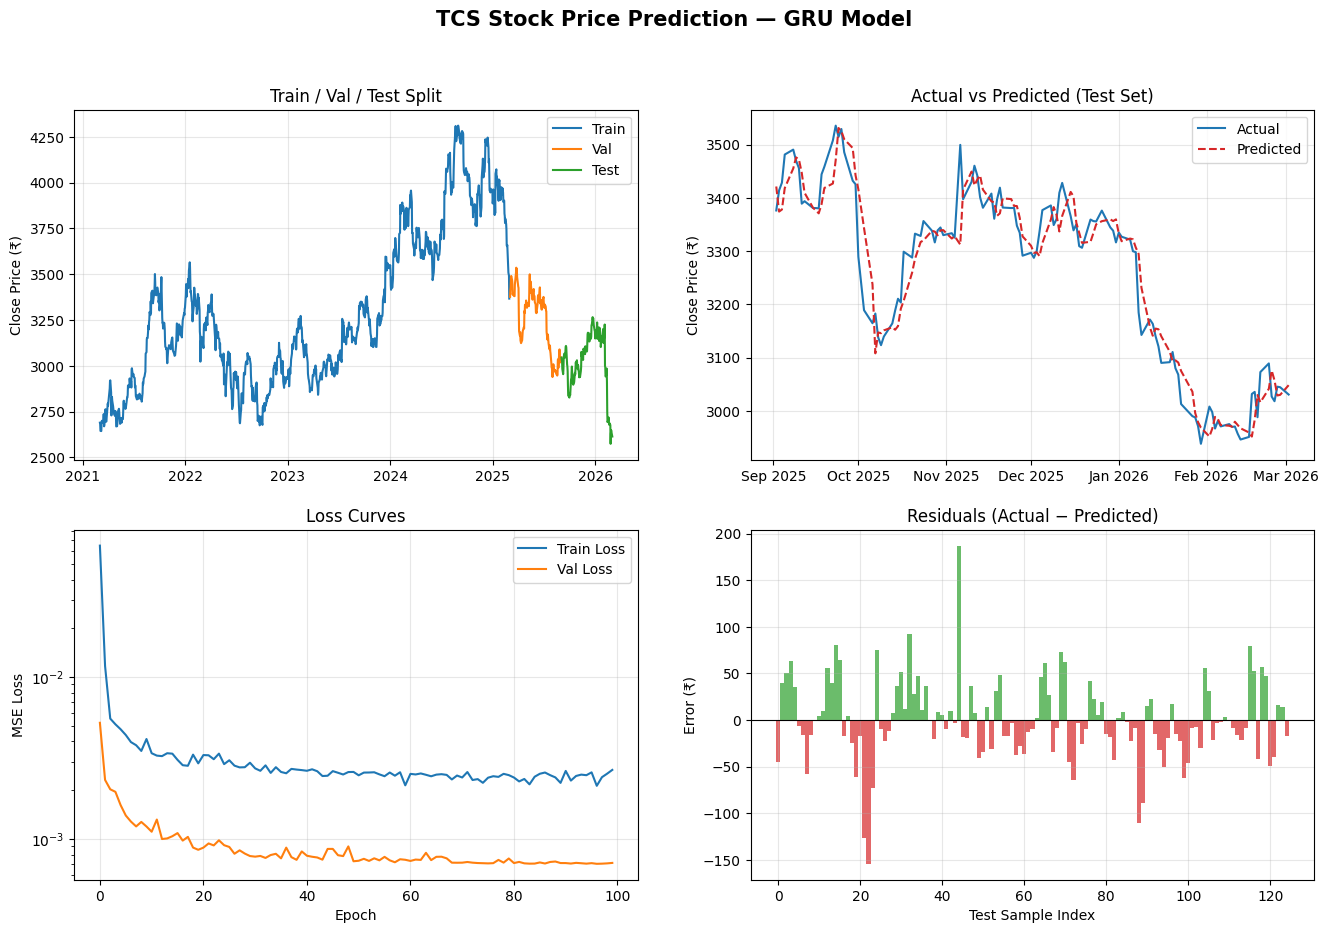

In [23]:
# ── 12. Plots ─────────────────────────────────────────────────────────────────
test_dates = dates[n_train + n_val : n_train + n_val + len(actuals)]
 
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("TCS Stock Price Prediction — GRU Model", fontsize=15, fontweight="bold")

# (a) Full price history
ax = axes[0, 0]
ax.plot(dates[:n_train], df["Close"].values[:n_train], label="Train", color="#1f77b4")
ax.plot(dates[n_train:n_train+n_val], df["Close"].values[n_train:n_train+n_val],
        label="Val", color="#ff7f0e")
ax.plot(dates[n_train+n_val:n_train+n_val+len(actuals)],
        df["Close"].values[n_train+n_val:n_train+n_val+len(actuals)],
        label="Test", color="#2ca02c")
ax.set_title("Train / Val / Test Split")
ax.set_ylabel("Close Price (₹)")
ax.legend(); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
 
# (b) Actual vs Predicted on test set
ax = axes[0, 1]
ax.plot(test_dates, actuals, label="Actual",    color="#1f77b4", linewidth=1.5)
ax.plot(test_dates, preds,   label="Predicted", color="#d62728",
        linewidth=1.5, linestyle="--")
ax.set_title("Actual vs Predicted (Test Set)")
ax.set_ylabel("Close Price (₹)")
ax.legend(); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
 
# (c) Training loss curve
ax = axes[1, 0]
ax.plot(train_losses, label="Train Loss", color="#1f77b4")
ax.plot(val_losses,   label="Val Loss",   color="#ff7f0e")
ax.set_title("Loss Curves")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.legend(); ax.grid(alpha=0.3)
ax.set_yscale("log")
 
# (d) Residuals
residuals = actuals - preds
ax = axes[1, 1]
ax.bar(range(len(residuals)), residuals, color=np.where(residuals >= 0, "#2ca02c", "#d62728"),
       alpha=0.7, width=1.0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Residuals (Actual − Predicted)")
ax.set_xlabel("Test Sample Index"); ax.set_ylabel("Error (₹)")
ax.grid(alpha=0.3)

In [26]:
# Metrics annotation
metrics_text = f"MAE: ₹{mae:.2f}\nRMSE: ₹{rmse:.2f}\nMAPE: {mape:.2f}%\nR²: {r2:.4f}"
fig.text(0.91, 0.5, metrics_text, fontsize=11,
         verticalalignment="center",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f0f0", alpha=0.8))
 
plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.savefig("tcs_gru_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → tcs_gru_results.png")

<Figure size 640x480 with 0 Axes>


Plot saved → tcs_gru_results.png


In [27]:
last_seq = torch.tensor(
    test_scaled[-SEQ_LEN:][np.newaxis, ...], dtype=torch.float32
).to(DEVICE)
 
model.eval()
with torch.no_grad():
    next_scaled = model(last_seq).item()
 
next_price = inverse_close([next_scaled], scaler, close_idx)[0]
print(f"\n📈 Predicted next-day TCS Close Price: ₹{next_price:.2f}")


📈 Predicted next-day TCS Close Price: ₹2721.55
